In [1]:
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from imblearn.over_sampling import SMOTE

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
df = pd.read_csv('/content/creditcard.csv')

print("First 5 rows of the dataset:")
print(df.head())

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nDataFrame Info:")
df.info()

print("\nDistribution of the 'Class' variable:")
print(df['Class'].value_counts())

First 5 rows of the dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

   

In [3]:
# Drop missing values
df_cleaned = df.dropna()
print(f"Shape after dropping missing values: {df_cleaned.shape}")

# Separate features and target
X = df_cleaned.drop(columns=['Time', 'Class'])
y = df_cleaned['Class']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape after dropping missing values: (17917, 31)
Shape of X: (17917, 29)
Shape of y: (17917,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train fraud count: {y_train.sum()}")
print(f"y_test  fraud count: {y_test.sum()}")

X_train: (14333, 29)
X_test:  (3584, 29)
y_train fraud count: 63.0
y_test  fraud count: 18.0


In [5]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribution after SMOTE:")
print(y_train_resampled.value_counts())

Distribution after SMOTE:
Class
0.0    14270
1.0    14270
Name: count, dtype: int64


In [6]:
model_performance = {}

def train_evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    model_performance[model_name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1-score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_pred_proba), 4),
    }

    print(f"\n--- {model_name} ---")
    for k, v in model_performance[model_name].items():
        print(f"  {k}: {v}")

    return model

print("Evaluation function ready.")

Evaluation function ready.


In [7]:
print("--- Training Pure Supervised Models ---")

log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
train_evaluate_model(log_reg_model, 'Logistic Regression',
                     X_train_resampled, y_train_resampled, X_test, y_test)

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
train_evaluate_model(rf_model, 'Random Forest',
                     X_train_resampled, y_train_resampled, X_test, y_test)

gbc_model = GradientBoostingClassifier(random_state=42)
train_evaluate_model(gbc_model, 'Gradient Boosting',
                     X_train_resampled, y_train_resampled, X_test, y_test)

--- Training Pure Supervised Models ---

--- Logistic Regression ---
  Accuracy: 0.9888
  Precision: 0.2963
  Recall: 0.8889
  F1-score: 0.4444
  ROC-AUC: 0.9975

--- Random Forest ---
  Accuracy: 0.9986
  Precision: 0.8824
  Recall: 0.8333
  F1-score: 0.8571
  ROC-AUC: 0.9996

--- Gradient Boosting ---
  Accuracy: 0.9986
  Precision: 0.8421
  Recall: 0.8889
  F1-score: 0.8649
  ROC-AUC: 0.9996


GradientBoostingClassifier(random_state=42)

In [8]:
fraud_rate = y_train.value_counts()[1.0] / len(y_train)
print(f"Fraud rate in training data: {fraud_rate:.4f}")

iso_forest = IsolationForest(random_state=42, contamination=fraud_rate, n_jobs=-1)
iso_forest.fit(X_train)

X_train_scores = iso_forest.decision_function(X_train)
X_test_scores  = iso_forest.decision_function(X_test)

print(f"Train anomaly scores shape: {X_train_scores.shape}")
print(f"Test  anomaly scores shape: {X_test_scores.shape}")

Fraud rate in training data: 0.0044
Train anomaly scores shape: (14333,)
Test  anomaly scores shape: (3584,)


In [9]:
X_train_hybrid = pd.concat([
    X_train.reset_index(drop=True),
    pd.Series(X_train_scores, name='Anomaly_Score')
], axis=1)

X_test_hybrid = pd.concat([
    X_test.reset_index(drop=True),
    pd.Series(X_test_scores, name='Anomaly_Score')
], axis=1)

smote_hybrid = SMOTE(random_state=42)
X_train_hybrid_resampled, y_train_hybrid_resampled = smote_hybrid.fit_resample(X_train_hybrid, y_train)

print(f"Hybrid train shape: {X_train_hybrid_resampled.shape}")
print(f"Hybrid test shape : {X_test_hybrid.shape}")
print(y_train_hybrid_resampled.value_counts())

Hybrid train shape: (28540, 30)
Hybrid test shape : (3584, 30)
Class
0.0    14270
1.0    14270
Name: count, dtype: int64


In [10]:
print("--- Training Hybrid Models ---")

log_reg_hybrid_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
train_evaluate_model(log_reg_hybrid_model, 'Hybrid Logistic Regression',
                     X_train_hybrid_resampled, y_train_hybrid_resampled, X_test_hybrid, y_test)

rf_hybrid_model = RandomForestClassifier(random_state=42, n_jobs=-1)
train_evaluate_model(rf_hybrid_model, 'Hybrid Random Forest',
                     X_train_hybrid_resampled, y_train_hybrid_resampled, X_test_hybrid, y_test)

gbc_hybrid_model = GradientBoostingClassifier(random_state=42)
train_evaluate_model(gbc_hybrid_model, 'Hybrid Gradient Boosting',
                     X_train_hybrid_resampled, y_train_hybrid_resampled, X_test_hybrid, y_test)

--- Training Hybrid Models ---

--- Hybrid Logistic Regression ---
  Accuracy: 0.9888
  Precision: 0.2963
  Recall: 0.8889
  F1-score: 0.4444
  ROC-AUC: 0.9974

--- Hybrid Random Forest ---
  Accuracy: 0.9986
  Precision: 0.8824
  Recall: 0.8333
  F1-score: 0.8571
  ROC-AUC: 0.9994

--- Hybrid Gradient Boosting ---
  Accuracy: 0.9986
  Precision: 0.8421
  Recall: 0.8889
  F1-score: 0.8649
  ROC-AUC: 0.9992


GradientBoostingClassifier(random_state=42)

In [11]:
performance_df = pd.DataFrame(model_performance).T
print(performance_df.to_markdown())

|                            |   Accuracy |   Precision |   Recall |   F1-score |   ROC-AUC |
|:---------------------------|-----------:|------------:|---------:|-----------:|----------:|
| Logistic Regression        |     0.9888 |      0.2963 |   0.8889 |     0.4444 |    0.9975 |
| Random Forest              |     0.9986 |      0.8824 |   0.8333 |     0.8571 |    0.9996 |
| Gradient Boosting          |     0.9986 |      0.8421 |   0.8889 |     0.8649 |    0.9996 |
| Hybrid Logistic Regression |     0.9888 |      0.2963 |   0.8889 |     0.4444 |    0.9974 |
| Hybrid Random Forest       |     0.9986 |      0.8824 |   0.8333 |     0.8571 |    0.9994 |
| Hybrid Gradient Boosting   |     0.9986 |      0.8421 |   0.8889 |     0.8649 |    0.9992 |


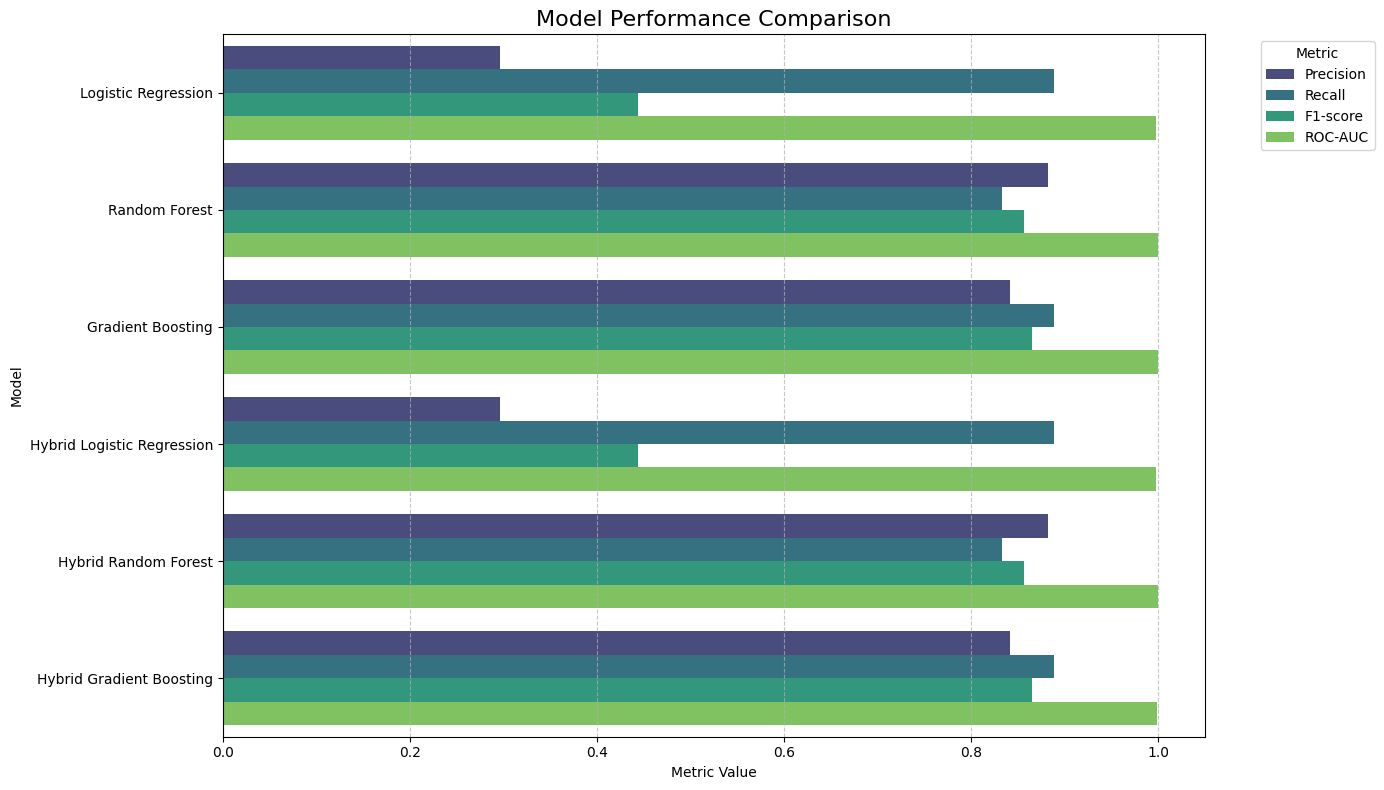

In [12]:
performance_df_reset = performance_df.reset_index().rename(columns={'index':'Model'})
performance_melted = performance_df_reset.melt(id_vars='Model', var_name='Metric', value_name='Value')
filtered = performance_melted[performance_melted['Metric'].isin(['Precision','Recall','F1-score','ROC-AUC'])]

plt.figure(figsize=(14, 8))
sns.barplot(x='Value', y='Model', hue='Metric', data=filtered, palette='viridis')
plt.title('Model Performance Comparison', fontsize=16)
plt.xlabel('Metric Value')
plt.ylabel('Model')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

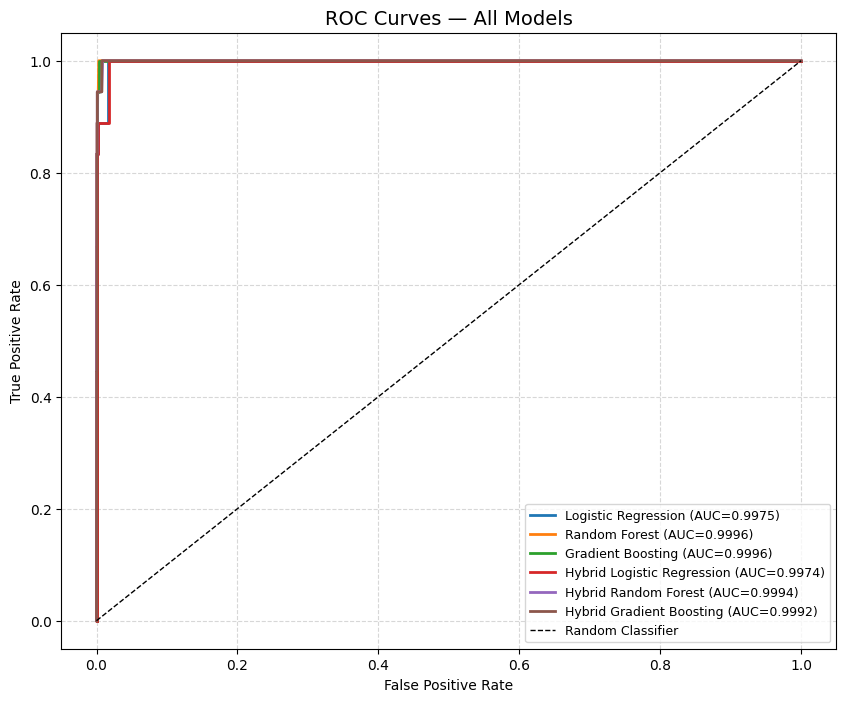

In [13]:
plt.figure(figsize=(10, 8))

models_dict = {
    'Logistic Regression'      : (log_reg_model,       X_test),
    'Random Forest'            : (rf_model,             X_test),
    'Gradient Boosting'        : (gbc_model,            X_test),
    'Hybrid Logistic Regression': (log_reg_hybrid_model, X_test_hybrid),
    'Hybrid Random Forest'     : (rf_hybrid_model,      X_test_hybrid),
    'Hybrid Gradient Boosting' : (gbc_hybrid_model,     X_test_hybrid),
}

colors = plt.colormaps.get_cmap('tab10')

for i, (name, (model, X_t)) in enumerate(models_dict.items()):
    y_prob = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors(i), lw=2, label=f'{name} (AUC={roc:.4f})')

plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()